# Behavioral distances

How far apart are two behavioural profiles? Everything in this notebook is a distance
between syllable profiles -- between sessions of the same mouse, between mice, or
between individual trials -- and the statistics that go with them.

Split out of `behavioral_entropy_v2.ipynb`, which mixed entropy measures with distance
measures. The entropy half stayed there; this half was fixed on the way over:

| was | now |
| --- | --- |
| within-mouse distances used `metric='jensenshannon'`, between-mouse used `np.linalg.norm` | one metric on both sides -- and the answer is reported for three metrics, because it should not depend on the choice |
| within = session-vs-session, between = mousemean-vs-mousemean | both sides session-vs-session, so both carry one session of noise |
| "chance level" = all session pairs, which *contains* the within-mouse pairs | chance level = mouse labels permuted across sessions |
| Mann-Whitney U over pairwise distances (n = tens of thousands of *dependent* pairs) | per-mouse paired Wilcoxon (n = mice) plus a label-permutation test; the invalid U is still printed, so the size of the pseudoreplication is visible |
| trial-level Hamming groups built by random subsampling of trial pairs (seed-dependent, hours of `cdist`) | closed form -- mean pairwise Hamming is an exact function of the marginal profiles, so it needs no pairs at all |
| the axis said "Cosine distance" | it says what was computed |

The identity in section 2 is the reason the sections are ordered this way: the
trial-level Hamming hierarchy and the session-profile distances are *the same
measurement*, not two independent pieces of evidence.

In [1]:
"""
SHARED FIGURE STYLE -- must run before the imports cell (that one does an os.chdir).
Colours, panel sizes, type and saving all come from paper-individuality/paper_style.py.
"""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / 'learning_individuality'))   # session_filters lives there
import importlib
import paper_style
importlib.reload(paper_style)   # kernels cache modules: without this, edits to
ps = paper_style                # paper_style stay invisible until a restart
ps.use('poster')      # 'poster' = big type for a poster; 'paper' = journal sizes

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

In [2]:
"""
IMPORTS
Only what a distance notebook needs. scipy.stats.entropy is gone with the entropy
analyses; mannwhitneyu is imported deliberately, to print the invalid p-value next to
the valid one in section 1.
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, cdist, squareform
from scipy.stats import pearsonr, spearmanr, wilcoxon, mannwhitneyu

# The two-tone grey pair used for within vs between throughout, so the same contrast
# means the same thing in every panel. Both come from the paper palette (they are the
# whisk/lick pair in ps.SYLLABLE_COLORS): 4.6:1 against each other, so they survive
# greyscale printing and every colour-vision deficiency.
WITHIN_C, BETWEEN_C = '#b8b8b8', '#484949'


def panels(ncols=1, kind='single', scale=0.78, hscale=1.0, **kw):
    """A row of `ncols` panels, each at the current mode's `kind` size."""
    w, h = ps.SIZES[ps.MODE][kind]
    ps.reapply()
    return plt.subplots(1, ncols, figsize=(w * scale * ncols, h * scale * hscale), **kw)

In [3]:
"""
PATHS AND SESSION EXCLUSIONS -- same scheme as the LDA scripts
==============================================================
Nothing is hardcoded to one machine or one file date any more: each path is resolved
from a candidate list, and the session exclusions come from the curated QC sheet via
session_filters rather than a list pasted into the notebook.
"""
BASE_CANDIDATES = [
    '/home/ines/repositories/representation_learning_variability/paper-individuality/data/',
    os.path.expanduser('~/Documents/Repositories/representation_learning_variability/'
                       'paper-individuality/data/'),
]
base_path = next((b for b in BASE_CANDIDATES if os.path.isdir(b)), None)
assert base_path is not None, "none of the candidate data folders exist:\n  " + "\n  ".join(BASE_CANDIDATES)

# the proficient syllable file, newest first
SYLLABLE_CANDIDATES = [base_path + '8_k_10_bin_syllables_19-08-2026',
                       base_path + 'paw_wheel_8_k_10_bin_syllables_04-09-2026',
                       base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026'
                       ]
syllable_file = next((f for f in SYLLABLE_CANDIDATES if os.path.exists(f)), None)
assert syllable_file is not None, "no syllable file found:\n  " + "\n  ".join(SYLLABLE_CANDIDATES)

# the mouse LDA embedding, newest first
_clu = os.path.abspath(os.path.join(base_path, '..', 'clustering'))
LDA_CANDIDATES = [os.path.join(_clu, 'mouse_LDA_5_bins_cut08-09-2026'),
                  os.path.join(_clu, 'data_files', 'mouse_LDA_5_bins_cut08-09-2026'),
                  os.path.join(_clu, 'data_files', 'mouse_LDA_5_bins_cut')]
lda_file = next((f for f in LDA_CANDIDATES if os.path.exists(f)), None)
assert lda_file is not None, "no LDA pickle found:\n  " + "\n  ".join(LDA_CANDIDATES)

""" SESSION EXCLUSIONS -- the curated QC sheet, not a hardcoded list """
# A long-lived kernel caches imported modules, so edits to session_filters -- or
# the QC sheet moving folders -- stay invisible until a restart. Reload explicitly.
import importlib, session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint, find_csv

QC_STRICTNESS = 'filtered_out'      # or 'filtered_out_and_revise'
_excl = exclusions_by_timepoint(QC_STRICTNESS)
prob_sessions = sorted(_excl['Proficient'])

prefix = os.path.abspath(os.path.join(base_path, '..', '..', '..')) + os.sep

print('repo root :', prefix)
print('syllables :', os.path.basename(syllable_file))
print('LDA       :', os.path.relpath(lda_file, _clu))
print('QC sheet  :', find_csv().name)
print(f'exclusions ({QC_STRICTNESS}): ' + ', '.join(f'{k} {len(v)}' for k, v in _excl.items())
      + f'  ->  {len(prob_sessions)} proficient sessions dropped')

repo root : /Users/ineslaranjeira/Documents/Repositories/
syllables : 8_k_10_bin_syllables_19-08-2026
LDA       : mouse_LDA_5_bins_cut08-09-2026
QC sheet  : individuality-paper_data_4Sep26.csv
exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12  ->  12 proficient sessions dropped


In [4]:
"""
BUILD THE DESIGN MATRIX -- the same two functions the LDA scripts use
====================================================================
filter_sequences drops the QC-excluded sessions and any mouse with fewer than 3
sessions; binarize turns the integer syllable codes into per-timestep indicators,
dropping paw state 1 as the redundant one-hot reference (8 paw states sum to 1), so
each timestep contributes 7 paw + whisk + lick = 9 features.

Downstream cells expect exactly the names produced here: design_df, use_format,
trial_syllables_m, SYLLABLE_COLS and the N_* constants.
"""
def filter_sequences(all_sequences, min_sessions=3):
    n0 = all_sequences['session'].nunique()
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)]
    n1 = all_sequences['session'].nunique()
    count = (all_sequences[['mouse_name', 'session']].drop_duplicates()
             .groupby('mouse_name')['session'].count().reset_index())
    keep = count.loc[count['session'] >= min_sessions, 'mouse_name']
    out = all_sequences.loc[all_sequences['mouse_name'].isin(keep)].reset_index(drop=True)
    print(f"{n0} sessions -> {n1} after QC -> {out['session'].nunique()} after the "
          f">= {min_sessions} sessions rule ({out['mouse_name'].nunique()} mice)")
    return out


def binarize(use_sequences, n_paw_states=8, keep_paw=True, keep_whisk=True, keep_lick=True):
    """Integer syllable codes -> per-timestep indicators (paw state 1 dropped)."""
    n_raw = n_paw_states + 2
    n_trials, timesteps = use_sequences.shape
    binarized = np.zeros((n_trials, timesteps * n_raw))
    for t in range(timesteps):
        vals = use_sequences[:, t]
        nan_mask = np.isnan(vals); valid = ~nan_mask
        labels = vals[valid].astype(int)
        start = t * n_raw
        if len(labels):
            rows = np.arange(n_trials)[valid]
            binarized[rows, start + (labels % n_paw_states)] = 1
            binarized[valid, start + n_paw_states] = ((labels // n_paw_states) % 2).astype(int)
            binarized[valid, start + n_paw_states + 1] = (labels // (n_paw_states * 2)).astype(int)
        if np.any(nan_mask):
            binarized[nan_mask, start:start + n_raw] = np.nan
    cols = []
    if keep_paw:   cols += [i for i in range(n_paw_states) if i != 1]
    if keep_whisk: cols += [n_paw_states]
    if keep_lick:  cols += [n_paw_states + 1]
    return binarized[:, [t * n_raw + c for t in range(timesteps) for c in cols]]


all_sequences = pd.read_parquet(syllable_file)
all_sequences['session'] = all_sequences['sample'].str[:36]
all_sequences = filter_sequences(all_sequences)

design_df = (all_sequences
             .pivot(index=['mouse_name', 'session', 'sample', 'trial_type'],
                    columns=['broader_label'], values='binned_sequence')
             .reset_index().dropna()
             .sort_values('session')
             .reset_index(drop=True))
assert len(design_df) > 0, 'design_df is empty after filtering'

EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
use_format = binarize(np.vstack(design_df[EPOCHS].apply(lambda r: np.hstack(r), axis=1)),
                      n_paw_states=8)

# The canonical feature columns, set once so later cells cannot pick up metric columns
# added along the way.
SYLLABLE_COLS = list(range(use_format.shape[1]))

# THE unit of observation for this notebook is the TRIAL: every distance here is either
# between trials or between averages of trials. Session means are derived in the next
# cell, never loaded from elsewhere.
trial_syllables = pd.DataFrame(use_format, columns=SYLLABLE_COLS)
trial_syllables['session'] = design_df['session'].values
trial_syllables = trial_syllables.dropna()
trial_syllables_m = trial_syllables.merge(
    design_df[['session', 'mouse_name']].drop_duplicates(), on='session', how='left')

# structure constants, derived rather than hardcoded
N_PAW_STATES = 7                      # after the reference state is dropped
N_SYLLABLES = N_PAW_STATES + 2        # + whisk + lick
N_TIMESTEPS = timesteps = use_format.shape[1] // N_SYLLABLES
n_paw_states = 8

rng = np.random.default_rng(0)        # every random draw below comes from this one

print(f"design_df: {len(design_df)} trials, {design_df['session'].nunique()} sessions, "
      f"{design_df['mouse_name'].nunique()} mice")
print(f"use_format: {use_format.shape} = {N_TIMESTEPS} timesteps x {N_SYLLABLES} syllables")

lda = pd.read_pickle(lda_file).rename(columns={0: 'lda_1'})
print(f"lda: {len(lda)} rows, {lda['mouse_name'].nunique()} mice")

332 sessions -> 330 after QC -> 269 after the >= 3 sessions rule (58 mice)
design_df: 166617 trials, 269 sessions, 58 mice
use_format: (166617, 360) = 40 timesteps x 9 syllables
lda: 269 rows, 58 mice


## What the distance is computed on

A **session profile** is the mean of that session's binarised trials: 360 numbers, each
the probability that one feature is "on" at one timestep. Probabilities, not counts.

It is emphatically **not** a probability distribution, and that is what wrecked the
Jensen-Shannon version of this analysis. Per timestep the vector holds 7 paw-state
indicators (state 1 dropped as the reference, so they sum to `1 - P(state 1) < 1`) plus
two independent Bernoullis, whisk and lick. The whole vector sums to roughly
`40 x (1 + p_whisk + p_lick)`, i.e. ~55, and *that sum is signal* -- a mouse that whisks
more has a bigger one. `scipy`'s `jensenshannon` silently divides each row by its sum
before it computes anything, so it (a) fuses the paw simplex across all 40 timesteps
with the whisk/lick Bernoullis into one fictitious 360-outcome distribution and (b)
divides out the activity level. It fails quietly, which is worse than failing loudly.

Three metrics are carried through section 1 instead, because a real effect must not
depend on which is chosen:

- **`hellinger`** -- the default. Hellinger distance between the Bernoulli pairs
  `(p, 1-p)` and `(q, 1-q)`, averaged over features. Implemented as plain Euclidean
  distance on the feature map `[sqrt(p), sqrt(1-p)] / sqrt(2d)`, so it lands in [0, 1].
  Preferred because `sqrt(p)` is the **variance-stabilising** transform for a
  proportion: raw features carry Bernoulli noise `p(1-p)/n`, so plain Euclidean lets
  features near `p = 0.5` dominate every distance purely by being noisiest, while a
  feature at `p = 0.02` contributes nothing even if a mouse doubles it. After the sqrt
  the noise is ~`1/(4n)` regardless of `p`.
- **`euclidean`** -- `||p - q|| / sqrt(d)`. No transform, kept as the control.
- **`hamming_gap`** -- `||p - q||^2 / d`, which section 2 shows *is* the trial-level
  Hamming excess, exactly.

On standardising within a session: don't. Z-scoring a session's 360 features against
each other removes that session's overall level and scale, and the level is part of who
the mouse is -- it normalises away the signal. Standardising per feature *across*
sessions is a different operation and defensible, but the pooled across-session spread
contains between-mouse variance, so it divides the effect by a quantity that contains
the effect. If a noise normalisation is wanted, the honest one is per-feature
**within-mouse** SD; the sqrt transform gets most of the way there and estimates
nothing.

In [5]:
"""
SESSION PROFILES -- the unit of section 1, 3 and 4
==================================================
One row per (mouse, session): the mean of that session's binarised trials.
"""
_g = trial_syllables_m.groupby(['mouse_name', 'session'], sort=False)

session_profiles = _g[SYLLABLE_COLS].mean()
profile_n_trials = _g.size().values
profile_mouse = session_profiles.index.get_level_values('mouse_name').to_numpy()
profile_session = session_profiles.index.get_level_values('session').to_numpy()
P = session_profiles.to_numpy(float)                 # (n_sessions, 360)
N_SESS, N_FEAT = P.shape

# The structure claim above, checked rather than asserted in prose
_paw = P.reshape(N_SESS, N_TIMESTEPS, N_SYLLABLES)[:, :, :N_PAW_STATES]
print(f'{N_SESS} sessions x {N_FEAT} features, {len(np.unique(profile_mouse))} mice')
print(f'trials per session: median {np.median(profile_n_trials):.0f} '
      f'(range {profile_n_trials.min()}-{profile_n_trials.max()})')
print(f'paw block sums to {_paw.sum(2).mean():.3f} per timestep on average '
      f'(= 1 - P(reference state)), NOT 1')
print(f'whole 360-vector sums to {P.sum(1).mean():.1f} '
      f'(range {P.sum(1).min():.1f}-{P.sum(1).max():.1f}), NOT 1')


def profile_features(Q, metric='hellinger'):
    """Feature map that turns a metric into a plain Euclidean distance.

    Returning a map rather than a distance means pdist/cdist/centroids/permutations all
    work off one code path -- and a centroid in the mapped space is what section 3's
    nearest-centroid classifier needs.

    hellinger    [sqrt(p), sqrt(1-p)] / sqrt(2d)  -> Euclidean = mean per-feature
                 Bernoulli Hellinger distance, in [0, 1]
    euclidean    p / sqrt(d)                      -> Euclidean = RMS difference in
                 probability, in [0, 1]
    hamming_gap  p / sqrt(d)                      -> SQUARED Euclidean = the exact
                 trial-level Hamming excess of section 2 (so distances are compared
                 after squaring; see `profile_distances`)
    """
    Q = np.clip(np.asarray(Q, float), 0, 1)
    d = Q.shape[1]
    if metric == 'hellinger':
        return np.hstack([np.sqrt(Q), np.sqrt(1 - Q)]) / np.sqrt(2 * d)
    if metric in ('euclidean', 'hamming_gap'):
        return Q / np.sqrt(d)
    raise ValueError(f'unknown metric {metric!r}')


def profile_distances(Q, metric='hellinger'):
    """Condensed pairwise distances between the rows of Q under `metric`."""
    dist = pdist(profile_features(Q, metric), 'euclidean')
    return dist ** 2 if metric == 'hamming_gap' else dist


METRICS = ['hellinger', 'euclidean', 'hamming_gap']

269 sessions x 360 features, 58 mice
trials per session: median 551 (range 41-1516)
paw block sums to 0.605 per timestep on average (= 1 - P(reference state)), NOT 1
whole 360-vector sums to 55.4 (range 36.6-76.8), NOT 1


wrote figures/distance_profile_overview_poster_08-09-2026.png


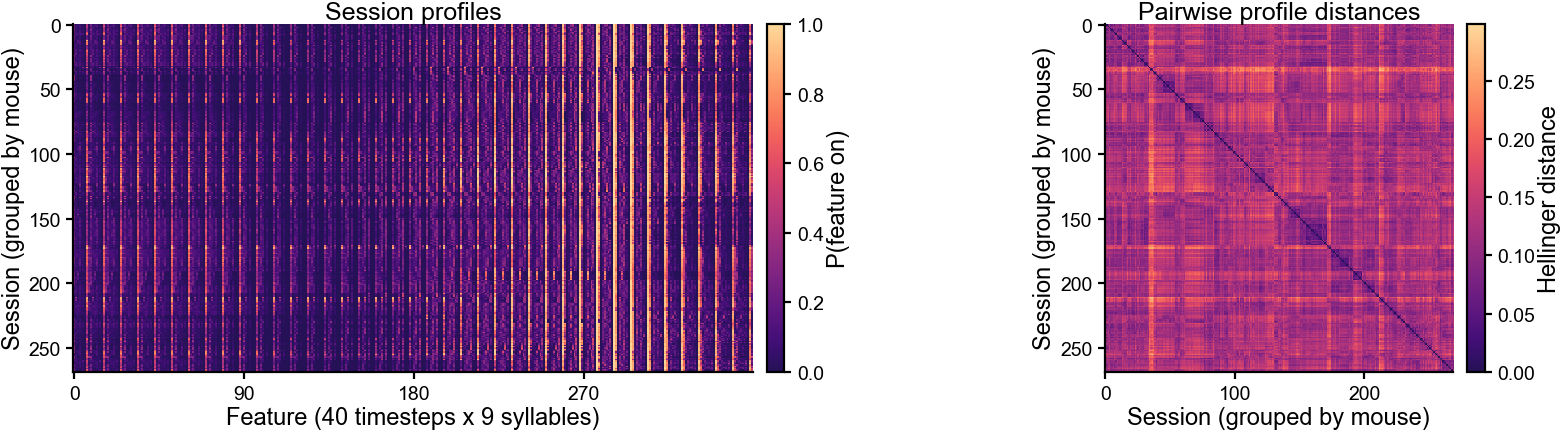

In [6]:
"""
The profile matrix, rows grouped by mouse -- a look at what the distances see.
"""
order = np.lexsort((profile_session, profile_mouse))
fig, axes = panels(2, kind='wide', scale=0.85)

im = axes[0].imshow(P[order], aspect='auto', cmap=ps.SEQUENTIAL_CMAP,
                    interpolation='none', vmin=0, vmax=1)
fig.colorbar(im, ax=axes[0], fraction=0.03, pad=0.02, label='P(feature on)')
axes[0].set_xticks(np.arange(0, N_FEAT, 90))
axes[0].set_xlabel('Feature (40 timesteps x 9 syllables)')
axes[0].set_ylabel('Session (grouped by mouse)')
axes[0].set_title('Session profiles')

# Within-mouse blocks should be visible as blocks on the diagonal if identity is real
D_show = squareform(profile_distances(P[order], 'hellinger'))
im = axes[1].imshow(D_show, cmap=ps.SEQUENTIAL_CMAP, interpolation='none')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.02, label='Hellinger distance')
axes[1].set_xlabel('Session (grouped by mouse)')
axes[1].set_ylabel('Session (grouped by mouse)')
axes[1].set_title('Pairwise profile distances')

plt.tight_layout()
ps.savefig(fig, 'distance_profile_overview')
plt.show()

## 1. Within-mouse vs between-mouse session profiles

The claim is that two sessions of the same mouse are more alike than two sessions of
different mice. For that to be a claim about mice and not about arithmetic, **both
sides must be the same kind of object**: a distance between two session profiles.

The old version compared session-vs-session (within) against mousemean-vs-mousemean
(between). Those estimate different quantities. With `sigma^2` the per-feature
session-level noise and `mu` a mouse's true profile,

- within  ~ `sqrt(2 sum sigma^2)` -- one session of noise on each side, nothing averaged
- between ~ `sqrt(||mu_i - mu_j||^2 + 2 sum sigma^2 / n_sessions)` -- real differences
  plus noise *shrunk* by averaging

which happens to be conservative here (it strips noise from the between side), but it
is not the comparison anyone means. Below, every distance is session-to-session.

In [7]:
"""
WITHIN vs BETWEEN, one metric on both sides, session level on both sides.
"""
iu = np.triu_indices(N_SESS, 1)
same_mouse = profile_mouse[iu[0]] == profile_mouse[iu[1]]
print(f'{same_mouse.sum()} within-mouse session pairs, {(~same_mouse).sum()} between-mouse pairs')

pair_dists = {m: profile_distances(P, m) for m in METRICS}

rows = []
for m in METRICS:
    dv = pair_dists[m]
    w, b = dv[same_mouse], dv[~same_mouse]
    ratio = b.mean() / w.mean()
    rows.append(dict(metric=m, within=w.mean(), within_sd=w.std(),
                     between=b.mean(), between_sd=b.std(), ratio=ratio,
                     # hamming_gap is a SQUARED distance, so its ratio is the square
                     # of the other two -- compared on the same footing here
                     ratio_as_distance=np.sqrt(ratio) if m == 'hamming_gap' else ratio,
                     # Cohen's d on the pairs, purely descriptive -- the pairs are not
                     # independent, so it is an effect size, never a test
                     cohens_d=(b.mean() - w.mean()) /
                              np.sqrt(0.5 * (w.var() + b.var()))))
metric_table = pd.DataFrame(rows).set_index('metric')
print(metric_table.round(4).to_string())
print('\nratio_as_distance is ~1.75 for all three, so the effect is in the data and not '
      'in the choice of\nmetric (hamming_gap is a squared distance, hence a raw ratio of '
      '~1.75^2). The old figure showed\na near-total separation only because within used '
      'JS distance -- bounded by sqrt(ln 2) = 0.83,\nin nats -- and between used raw '
      'Euclidean on 360 features. Different units, not different mice.')

# What the two mismatched metrics actually looked like, for the record
_js = pdist(P, 'jensenshannon')          # scipy normalises each row by its sum first
_eu = pdist(P, 'euclidean')              # what np.linalg.norm was computing
print(f'\nold cell, within  (JS, nats)      : mean {_js[same_mouse].mean():.4f}')
print(f'old cell, between (raw Euclidean) : mean {_eu[~same_mouse].mean():.4f}'
      f'   <- {_eu[~same_mouse].mean() / _js[same_mouse].mean():.0f}x larger by construction')

627 within-mouse session pairs, 35419 between-mouse pairs
             within  within_sd  between  between_sd   ratio  ratio_as_distance  cohens_d
metric                                                                                  
hellinger    0.0736     0.0276   0.1283      0.0295  1.7432             1.7432    1.9154
euclidean    0.0738     0.0298   0.1317      0.0334  1.7846             1.7846    1.8303
hamming_gap  0.0063     0.0056   0.0185      0.0097  2.9145             1.7072    1.5295

ratio_as_distance is ~1.75 for all three, so the effect is in the data and not in the choice of
metric (hamming_gap is a squared distance, hence a raw ratio of ~1.75^2). The old figure showed
a near-total separation only because within used JS distance -- bounded by sqrt(ln 2) = 0.83,
in nats -- and between used raw Euclidean on 360 features. Different units, not different mice.

old cell, within  (JS, nats)      : mean 0.1617
old cell, between (raw Euclidean) : mean 2.4984   <- 15x larger b

In [8]:
"""
STATISTICS -- why the Mann-Whitney had to go
============================================
Pairwise distances are not independent observations: each of the 269 sessions appears
in 268 pairs. Mann-Whitney's p-value counts them as independent, so it is not a test of
anything -- with tens of thousands of pairs it reports p ~ 0 for an effect of any size.
It is printed first only so the size of the pseudoreplication is visible.

Two tests replace it:

1. PER-MOUSE PAIRED WILCOXON. One within number and one between number per mouse, then
   a signed-rank test across mice. n = mice, which is the number of independent units
   there actually are.
2. LABEL PERMUTATION. Statistic = mean(between) - mean(within) over all pairs; the null
   shuffles mouse labels across sessions, which is exactly the hypothesis "sessions are
   exchangeable between mice" and which reproduces the dependence structure in every
   surrogate.
"""
METRIC = 'hellinger'          # the headline metric; re-run this cell with another
dv = pair_dists[METRIC]

# --- 0. the invalid one, for scale ---
u_stat, u_p = mannwhitneyu(dv[same_mouse], dv[~same_mouse], alternative='less')
print(f'[INVALID] Mann-Whitney on {len(dv)} dependent pairs: U={u_stat:.0f}, p={u_p:.1e}')

# --- 1. per-mouse paired ---
D_full = squareform(dv)
rows = []
for m in np.unique(profile_mouse):
    i = np.where(profile_mouse == m)[0]
    o = np.where(profile_mouse != m)[0]
    if len(i) < 2:
        continue                      # needs >= 2 sessions for a within-mouse distance
    rows.append(dict(mouse_name=m, n_sessions=len(i),
                     within=D_full[np.ix_(i, i)][np.triu_indices(len(i), 1)].mean(),
                     between=D_full[np.ix_(i, o)].mean()))
mouse_dist = pd.DataFrame(rows)
mouse_dist['gap'] = mouse_dist['between'] - mouse_dist['within']

w_stat, w_p = wilcoxon(mouse_dist['within'], mouse_dist['between'], alternative='less')
n_mice = len(mouse_dist)
print(f'[VALID]   per-mouse Wilcoxon: n={n_mice} mice, '
      f'within {mouse_dist["within"].mean():.4f} vs between {mouse_dist["between"].mean():.4f}, '
      f'W={w_stat:.0f}, p={w_p:.2e}')
print(f'          within < between in {(mouse_dist["within"] < mouse_dist["between"]).sum()}'
      f'/{n_mice} mice')

# --- 2. label permutation ---
N_PERM = 5000
obs = dv[~same_mouse].mean() - dv[same_mouse].mean()
null = np.empty(N_PERM)
for k in range(N_PERM):
    lab = rng.permutation(profile_mouse)
    s = lab[iu[0]] == lab[iu[1]]
    null[k] = dv[~s].mean() - dv[s].mean()
p_perm = (1 + np.sum(null >= obs)) / (N_PERM + 1)
z_perm = (obs - null.mean()) / null.std()
print(f'[VALID]   label permutation ({N_PERM} shuffles): observed gap {obs:.4f}, '
      f'null {null.mean():+.4f} +- {null.std():.4f}, z={z_perm:.1f}, p={p_perm:.1e} '
      f'(floor 1/{N_PERM + 1})')

[INVALID] Mann-Whitney on 36046 dependent pairs: U=1895798, p=1.1e-278
[VALID]   per-mouse Wilcoxon: n=58 mice, within 0.0743 vs between 0.1278, W=0, p=1.75e-11
          within < between in 58/58 mice
[VALID]   label permutation (5000 shuffles): observed gap 0.0547, null +0.0000 +- 0.0016, z=35.1, p=2.0e-04 (floor 1/5001)


wrote figures/distance_within_between_mouse_poster_08-09-2026.png


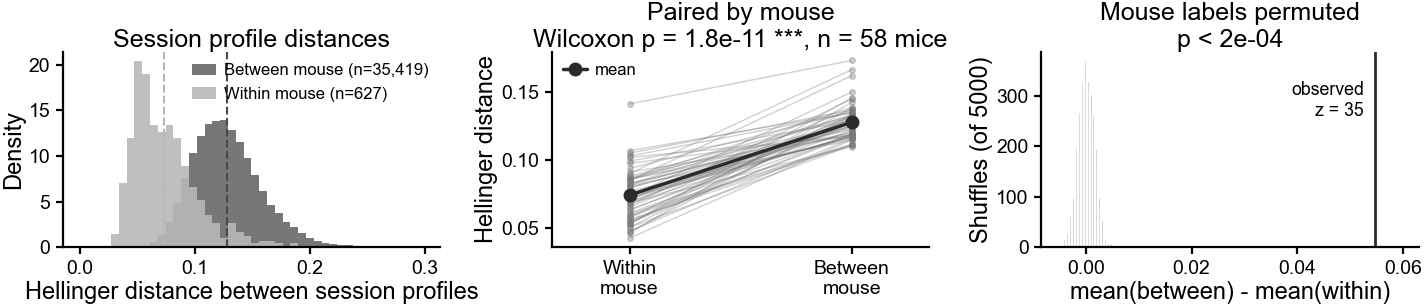

In [18]:
"""
FIGURE 1 -- within vs between mouse, with the honest null.
"""
fig, axes = panels(3, kind='single', scale=0.7)

# (0) the two distance distributions
ax = axes[0]
bins = np.linspace(0, max(dv.max(), 1e-9), 45)
ax.hist(dv[~same_mouse], bins=bins, density=True, color=BETWEEN_C, alpha=0.75,
        label=f'Between mouse (n={(~same_mouse).sum():,})')
ax.hist(dv[same_mouse], bins=bins, density=True, color=WITHIN_C, alpha=0.9,
        label=f'Within mouse (n={same_mouse.sum():,})')
for arr, c in [(dv[same_mouse], WITHIN_C), (dv[~same_mouse], BETWEEN_C)]:
    ax.axvline(arr.mean(), color=c, ls='--', lw=1.5)
ax.set_xlabel('Hellinger distance between session profiles')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.75)
ax.set_title('Session profile distances')

# (1) one line per mouse -- the unit the test actually uses
ax = axes[1]
for _, r in mouse_dist.iterrows():
    ax.plot([0, 1], [r['within'], r['between']], color=ps.NEUTRAL, alpha=0.35, lw=1,
            marker='o', ms=plt.rcParams['lines.markersize'] * 0.45, zorder=2)
ax.plot([0, 1], [mouse_dist['within'].mean(), mouse_dist['between'].mean()],
        color=ps.STATE_INK, lw=2.5, marker='o', zorder=3, label='mean')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Within\nmouse', 'Between\nmouse'])
ax.set_xlim(-0.35, 1.35)
ax.set_ylabel('Hellinger distance')
ax.set_title(f'Paired by mouse\nWilcoxon p = {w_p:.1e} {ps.stars(w_p)}, n = {n_mice} mice')
ax.legend(frameon=False, loc='upper left', fontsize=plt.rcParams['font.size'] * 0.75)

# (2) permutation null
ax = axes[2]
ax.hist(null, bins=40, color=WITHIN_C, edgecolor='white')
ax.axvline(obs, color=ps.STATE_INK, lw=2)
ax.annotate(f'observed\nz = {z_perm:.0f}', xy=(obs, ax.get_ylim()[1] * 0.75),
            xytext=(-8, 0), textcoords='offset points', ha='right', va='center',
            fontsize=plt.rcParams['font.size'] * 0.8)
ax.set_xlim(min(null.min(), 0) * 1.5, obs * 1.15)
ax.set_xlabel('mean(between) - mean(within)')
ax.set_ylabel(f'Shuffles (of {N_PERM})')
ax.set_title(f'Mouse labels permuted\np < {1 / N_PERM:.0e}')

plt.tight_layout()
ps.savefig(fig, 'distance_within_between_mouse')
plt.show()

In [10]:
"""
ROBUSTNESS -- equal trial counts per session
============================================
A profile from a 1500-trial session is a less noisy estimate than one from a 41-trial
session, and noise inflates every distance it touches. Sessions are not matched for
trial count anywhere above, so: redo the comparison with every session subsampled to
the same number of trials. The gap must survive, and it must shrink (fewer trials =
noisier profiles = larger distances on both sides).
"""
N_KEEP = 150            # ~ the 5th percentile of trials per session
N_DRAWS = 20

blocks = [g[SYLLABLE_COLS].to_numpy(float)
          for _, g in trial_syllables_m.groupby(['mouse_name', 'session'], sort=False)]
sub_rows = []
for draw in range(N_DRAWS):
    Ps = np.array([b[rng.choice(len(b), N_KEEP, replace=len(b) < N_KEEP)].mean(0)
                   for b in blocks])
    dvs = profile_distances(Ps, METRIC)
    sub_rows.append(dict(within=dvs[same_mouse].mean(), between=dvs[~same_mouse].mean()))
sub = pd.DataFrame(sub_rows)
sub['ratio'] = sub['between'] / sub['within']

print(f'all trials                 : within {dv[same_mouse].mean():.4f}  '
      f'between {dv[~same_mouse].mean():.4f}  ratio {metric_table.loc[METRIC, "ratio"]:.3f}')
print(f'{N_KEEP} trials/session ({N_DRAWS} draws): within {sub["within"].mean():.4f}  '
      f'between {sub["between"].mean():.4f}  ratio {sub["ratio"].mean():.3f} '
      f'+- {sub["ratio"].std():.3f}')
print('Both distances grow and the ratio shrinks, exactly as added noise predicts; '
      'the ordering is untouched.')

all trials                 : within 0.0736  between 0.1283  ratio 1.743
150 trials/session (20 draws): within 0.0837  between 0.1350  ratio 1.613 +- 0.007
Both distances grow and the ratio shrinks, exactly as added noise predicts; the ordering is untouched.


## 2. The trial-level Hamming hierarchy is the same measurement

The old cells built three groups of trial-to-trial Hamming distances -- within session,
across sessions of one mouse, across mice -- by sampling up to 500 random trial pairs
per block, which made the result depend on the seed and cost a lot of `cdist`. None of
that is necessary, and the reason is worth knowing.

Hamming distance on 0/1 vectors decomposes feature by feature, so the **mean** over
pairs only ever depends on the marginal profiles. For two blocks of trials with profiles
`p` and `q`:

    mean pairwise Hamming(p-block, q-block) = mean_f [ p_f + q_f - 2 p_f q_f ]

and inside one block of `n` trials, with `k_f` trials having feature `f` on, the exact
mean over the `n(n-1)/2` distinct pairs is

    mean pairwise Hamming(block)            = mean_f [ 2 k_f (n - k_f) / (n (n-1)) ]

Both are exact, O(n x d), no pairs enumerated, no subsampling, no seed. Subtracting one
from the other gives the identity that collapses the two analyses into one:

    Hamming(s, t) - [Hamming(s) + Hamming(t)] / 2 = mean_f (p_sf - p_tf)^2
                                                  = ||p_s - p_t||^2 / d

So **the excess Hamming distance between two blocks is the squared Euclidean distance
between their profiles** -- the `hamming_gap` metric of section 1. The three-level
"behavioural consistency hierarchy" is not independent evidence for individuality; it is
section 1 in different units. Two consequences worth stating in a caption:

- within-session Hamming is `mean_f 2 p_f (1 - p_f)`, i.e. the mean Bernoulli variance
  of that session and nothing else. So normalising it by "expected Hamming from base
  rates" (as the old cell did) divides a quantity by itself and gives ~1 by
  construction.
- mean Hamming is blind to every correlation between features. Anything about temporal
  structure or syllable co-occurrence needs a statistic that is not a mean of pairwise
  Hamming distances.

In [11]:
"""
Exact trial-level Hamming, from the marginals -- and the identity, checked.
"""
K = _g[SYLLABLE_COLS].sum().to_numpy(float)        # ones per feature per session
n_tr = profile_n_trials[:, None]

# within-session, exact mean over distinct trial pairs (excludes self-pairs)
hamming_within = (2 * K * (n_tr - K) / (n_tr * (n_tr - 1))).mean(1)
# the population version, which is what the identity uses
hamming_pop = (2 * P * (1 - P)).mean(1)

# every cross-session pair at once: mean_f [p + q - 2pq]
_G = P @ (1 - P).T
H_cross = (_G + _G.T) / N_FEAT
np.fill_diagonal(H_cross, np.nan)

# --- checks against the brute force the old cells were doing ---
_i, _j = 0, 1
_A = trial_syllables_m.loc[(trial_syllables_m['session'] == profile_session[_i]),
                           SYLLABLE_COLS].to_numpy(float)
_B = trial_syllables_m.loc[(trial_syllables_m['session'] == profile_session[_j]),
                           SYLLABLE_COLS].to_numpy(float)
assert np.isclose(pdist(_A, 'hamming').mean(), hamming_within[_i]), 'within-session form'
assert np.isclose(cdist(_A, _B, 'hamming').mean(), H_cross[_i, _j]), 'cross-session form'
_gap = H_cross - (hamming_pop[:, None] + hamming_pop[None, :]) / 2
_sq = squareform(profile_distances(P, 'hamming_gap'))
np.fill_diagonal(_sq, np.nan)
print(f'closed forms match brute-force cdist/pdist; identity holds to '
      f'{np.nanmax(np.abs(_gap - _sq)):.1e}')

# --- the hierarchy, exactly ---
hx = H_cross[iu]
print(f'\nwithin session            {hamming_within.mean():.4f} +- {hamming_within.std():.4f}'
      f'   (n={N_SESS} sessions)')
print(f'across sessions, same mouse {hx[same_mouse].mean():.4f}'
      f'   (n={same_mouse.sum()} pairs)')
print(f'across mice                 {hx[~same_mouse].mean():.4f}'
      f'   (n={(~same_mouse).sum()} pairs)')

# --- per-mouse paired tests, the same unit as section 1 ---
rows = []
H_same = H_cross.copy()
for m in np.unique(profile_mouse):
    i = np.where(profile_mouse == m)[0]
    o = np.where(profile_mouse != m)[0]
    if len(i) < 2:
        continue
    rows.append(dict(mouse_name=m, n_sessions=len(i),
                     within_session=hamming_within[i].mean(),
                     across_session=H_same[np.ix_(i, i)][np.triu_indices(len(i), 1)].mean(),
                     across_mouse=H_same[np.ix_(i, o)].mean()))
mouse_hamming = pd.DataFrame(rows)

p_ws_as = wilcoxon(mouse_hamming['within_session'], mouse_hamming['across_session'],
                   alternative='less')[1]
p_as_am = wilcoxon(mouse_hamming['across_session'], mouse_hamming['across_mouse'],
                   alternative='less')[1]
print(f'\nper-mouse Wilcoxon (n={len(mouse_hamming)} mice)')
print(f'  within session < across session : p = {p_ws_as:.2e} '
      f'({(mouse_hamming["within_session"] < mouse_hamming["across_session"]).sum()}'
      f'/{len(mouse_hamming)} mice)')
print(f'  across session < across mouse   : p = {p_as_am:.2e} '
      f'({(mouse_hamming["across_session"] < mouse_hamming["across_mouse"]).sum()}'
      f'/{len(mouse_hamming)} mice)')

closed forms match brute-force cdist/pdist; identity holds to 2.8e-16

within session            0.1619 +- 0.0177   (n=269 sessions)
across sessions, same mouse 0.1667   (n=627 pairs)
across mice                 0.1800   (n=35419 pairs)

per-mouse Wilcoxon (n=58 mice)
  within session < across session : p = 1.75e-11 (58/58 mice)
  across session < across mouse   : p = 6.55e-10 (51/58 mice)


wrote figures/distance_hamming_hierarchy_poster_08-09-2026.png


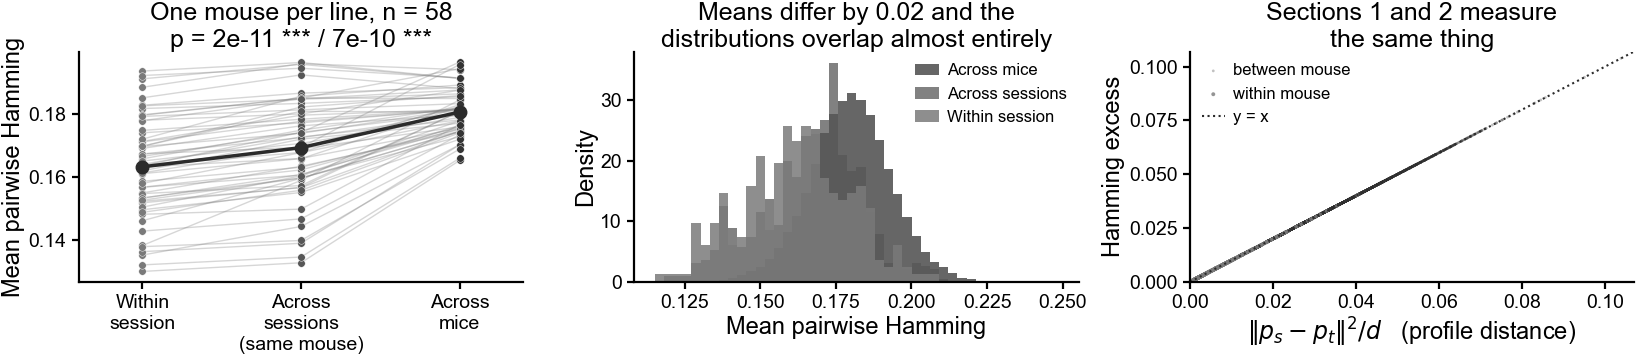

In [12]:
"""
FIGURE 2 -- the hierarchy, and the identity that explains it.
"""
fig, axes = panels(3, kind='single', scale=0.8)
levels = ['within_session', 'across_session', 'across_mouse']
labels = ['Within\nsession', 'Across\nsessions\n(same mouse)', 'Across\nmice']
# ordered variable -> one hue, deepening. ps.shade is the paper's way of doing that.
shades = [ps.shade(ps.NEUTRAL, w) for w in (0.0, 0.5, 1.0)]

# (0) per-mouse paired lines
ax = axes[0]
for _, r in mouse_hamming.iterrows():
    ax.plot(range(3), [r[c] for c in levels], color=ps.NEUTRAL, alpha=0.3, lw=1, zorder=2)
for k, (c, s) in enumerate(zip(levels, shades)):
    ax.scatter(np.full(len(mouse_hamming), k), mouse_hamming[c], color=s,
               s=(plt.rcParams['lines.markersize'] * 0.6) ** 2, zorder=3,
               edgecolors='white', linewidths=0.3)
ax.plot(range(3), [mouse_hamming[c].mean() for c in levels], color=ps.STATE_INK,
        lw=2.5, marker='o', zorder=4)
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_xlim(-0.4, 2.4)
ax.set_ylabel('Mean pairwise Hamming')
ax.set_title(f'One mouse per line, n = {len(mouse_hamming)}\n'
             f'p = {p_ws_as:.0e} {ps.stars(p_ws_as)} / {p_as_am:.0e} {ps.stars(p_as_am)}')

# (1) the pair distributions, exact -- note how small the differences are
ax = axes[1]
bins = np.linspace(min(hamming_within.min(), hx.min()), hx.max(), 45)
ax.hist(hx[~same_mouse], bins=bins, density=True, color=shades[2], alpha=0.75,
        label='Across mice')
ax.hist(hx[same_mouse], bins=bins, density=True, color=shades[1], alpha=0.75,
        label='Across sessions')
ax.hist(hamming_within, bins=bins, density=True, color=shades[0], alpha=0.85,
        label='Within session')
ax.set_xlabel('Mean pairwise Hamming')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.75)
ax.set_title('Means differ by 0.02 and the\ndistributions overlap almost entirely')

# (2) the identity
ax = axes[2]
x = _sq[iu]; y = _gap[iu]
ax.scatter(x[~same_mouse], y[~same_mouse], s=4, color=shades[2], alpha=0.3,
           label='between mouse', edgecolors='none')
ax.scatter(x[same_mouse], y[same_mouse], s=8, color=shades[0], alpha=0.8,
           label='within mouse', edgecolors='none')
lims = [0, np.nanmax(x) * 1.03]
ax.plot(lims, lims, color=ps.STATE_INK, ls=':', lw=1.5, label='y = x')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'$\|p_s - p_t\|^2 / d$   (profile distance)')
ax.set_ylabel('Hamming excess')
ax.legend(frameon=False, loc='upper left', fontsize=plt.rcParams['font.size'] * 0.75)
ax.set_title('Sections 1 and 2 measure\nthe same thing')

plt.tight_layout()
ps.savefig(fig, 'distance_hamming_hierarchy')
plt.show()

## 3. Can the mouse be identified from a held-out session?

Two overlapping histograms are a weak way to show individuality; an identification score
is a strong one, and it is immune to the whole question of which metric and which units.

Leave one session out, build each mouse's centroid from its remaining sessions (in the
`hellinger` feature space, so the centroid is the mean of variance-stabilised
profiles), assign the held-out session to the nearest centroid, and ask how often that
is the right mouse. Chance is `1/n_mice`; the honest null is the same procedure with
mouse labels permuted, which also absorbs any bias from mice having different numbers of
sessions.

In [13]:
"""
LEAVE-ONE-SESSION-OUT NEAREST-CENTROID MOUSE IDENTIFICATION
"""
F = profile_features(P, 'hellinger')


def loso_identify(F, labels):
    """Hit/miss and prediction for every session, its own mouse's centroid recomputed
    without it. Sums are cached so the leave-one-out is a subtraction, not a refit."""
    mice = np.unique(labels)
    at = {m: i for i, m in enumerate(mice)}
    S = np.array([F[labels == m].sum(0) for m in mice])
    C = np.array([(labels == m).sum() for m in mice], float)
    hit = np.zeros(len(F), bool)
    pred = np.empty(len(F), dtype=object)
    for i in range(len(F)):
        k = at[labels[i]]
        cent = S / C[:, None]
        cent[k] = (S[k] - F[i]) / (C[k] - 1)        # drop this session from its own mouse
        j = int(np.argmin(((cent - F[i]) ** 2).sum(1)))
        pred[i] = mice[j]
        hit[i] = mice[j] == labels[i]
    return hit, pred


hit, pred = loso_identify(F, profile_mouse)
acc = hit.mean()
n_mice_id = len(np.unique(profile_mouse))

N_PERM_ID = 1000
null_acc = np.array([loso_identify(F, rng.permutation(profile_mouse))[0].mean()
                     for _ in range(N_PERM_ID)])
p_id = (1 + np.sum(null_acc >= acc)) / (N_PERM_ID + 1)

print(f'LOSO identification: {hit.sum()}/{len(hit)} sessions = {acc:.1%} correct '
      f'out of {n_mice_id} mice')
print(f'chance             : {1 / n_mice_id:.1%}')
print(f'permuted labels    : {null_acc.mean():.1%} +- {null_acc.std():.1%}, '
      f'p = {p_id:.1e} (floor 1/{N_PERM_ID + 1})')

per_mouse_acc = (pd.DataFrame({'mouse_name': profile_mouse, 'hit': hit})
                 .groupby('mouse_name')['hit'].agg(accuracy='mean', n_sessions='size'))
print(f'\nper mouse: median {per_mouse_acc["accuracy"].median():.0%}, '
      f'{(per_mouse_acc["accuracy"] == 1).sum()}/{len(per_mouse_acc)} mice identified '
      f'in every session, {(per_mouse_acc["accuracy"] == 0).sum()} never identified')

LOSO identification: 210/269 sessions = 78.1% correct out of 58 mice
chance             : 1.7%
permuted labels    : 1.7% +- 0.9%, p = 1.0e-03 (floor 1/1001)

per mouse: median 80%, 22/58 mice identified in every session, 1 never identified


wrote figures/distance_mouse_identification_poster_08-09-2026.png


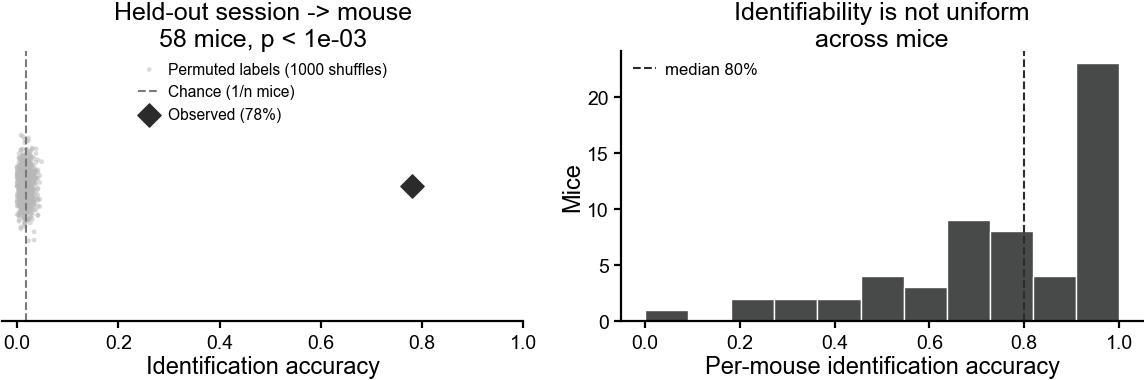

In [14]:
"""
FIGURE 3 -- identification accuracy against a permuted null.
"""
fig, axes = panels(2, kind='single', scale=0.85)

# A histogram of the null is invisible next to the observed value -- the null sits at
# 1.6% and the observation at 78% -- so the null is drawn as the cloud of points it is.
ax = axes[0]
ax.scatter(null_acc, rng.normal(0, 0.06, len(null_acc)), s=12, color=WITHIN_C,
           alpha=0.5, edgecolors='none', label=f'Permuted labels ({N_PERM_ID} shuffles)')
ax.axvline(1 / n_mice_id, color=ps.NEUTRAL, ls='--', lw=1.5, label='Chance (1/n mice)')
ax.scatter([acc], [0], s=140, color=ps.STATE_INK, marker='D', zorder=4,
           label=f'Observed ({acc:.0%})')
ax.set_xlim(-0.03, 1.0); ax.set_ylim(-0.5, 0.5)
ax.set_yticks([]); ax.spines['left'].set_visible(False)
ax.set_xlabel('Identification accuracy')
ax.legend(frameon=False, loc='upper center', fontsize=plt.rcParams['font.size'] * 0.7)
ax.set_title(f'Held-out session -> mouse\n{n_mice_id} mice, p < {1 / N_PERM_ID:.0e}')

ax = axes[1]
ax.hist(per_mouse_acc['accuracy'], bins=np.linspace(0, 1, 12), color=BETWEEN_C,
        edgecolor='white')
ax.axvline(per_mouse_acc['accuracy'].median(), color=ps.STATE_INK, ls='--', lw=1.5,
           label=f'median {per_mouse_acc["accuracy"].median():.0%}')
ax.set_xlabel('Per-mouse identification accuracy')
ax.set_ylabel('Mice')
ax.legend(frameon=False, fontsize=plt.rcParams['font.size'] * 0.75)
ax.set_title('Identifiability is not uniform\nacross mice')

plt.tight_layout()
ps.savefig(fig, 'distance_mouse_identification')
plt.show()

## 4. Distance-based variability vs LD1

The two session-level scalars this notebook produces, against the LDA-1 embedding:

- **within-session Hamming** -- trial-to-trial variability inside a session, which
  section 2 showed equals the mean Bernoulli variance of the session profile.
- **atypicality** -- how far a session sits from its own mouse's centroid (that session
  left out), i.e. within-mouse variability resolved per session rather than per mouse.

Both are distances, so they belong here rather than in the entropy notebook. The trial
count panel is the bias check: mean pairwise Hamming has the `n/(n-1)` correction
applied, so it should be flat in trial count, and any correlation with LD1 must not be a
correlation with session length.

In [15]:
"""
Session-level distance metrics, merged with LD1.
"""
atypicality = np.empty(N_SESS)
for m in np.unique(profile_mouse):
    i = np.where(profile_mouse == m)[0]
    S = F[i].sum(0)
    for ii in i:
        cent = (S - F[ii]) / (len(i) - 1)          # leave-one-out own-mouse centroid
        atypicality[ii] = np.sqrt(((F[ii] - cent) ** 2).sum())

session_metrics = pd.DataFrame({
    'mouse_name':      profile_mouse,
    'session':         profile_session,
    'n_trials':        profile_n_trials,
    'hamming_within':  hamming_within,
    'atypicality':     atypicality,
})

session_lda = lda.groupby('session')['lda_1'].mean().reset_index()
merged = session_metrics.merge(session_lda, on='session', how='inner').dropna()
print(f'{len(merged)}/{N_SESS} sessions have an LD1 value')

for col in ['hamming_within', 'atypicality', 'n_trials']:
    r, p = pearsonr(merged[col], merged['lda_1'])
    rho, pp = spearmanr(merged[col], merged['lda_1'])
    print(f'{col:16s} vs LD1: r = {r:+.3f} (p = {p:.1e}), rho = {rho:+.3f} (p = {pp:.1e})')

# mouse level, where the observations are independent
by_mouse = merged.groupby('mouse_name')[['hamming_within', 'atypicality', 'lda_1']].mean()
for col in ['hamming_within', 'atypicality']:
    r, p = pearsonr(by_mouse[col], by_mouse['lda_1'])
    print(f'{col:16s} vs LD1, MOUSE level (n={len(by_mouse)}): r = {r:+.3f} (p = {p:.1e})')

269/269 sessions have an LD1 value
hamming_within   vs LD1: r = -0.323 (p = 5.7e-08), rho = -0.300 (p = 5.6e-07)
atypicality      vs LD1: r = -0.089 (p = 1.4e-01), rho = -0.195 (p = 1.3e-03)
n_trials         vs LD1: r = +0.039 (p = 5.3e-01), rho = +0.055 (p = 3.7e-01)
hamming_within   vs LD1, MOUSE level (n=58): r = -0.337 (p = 9.7e-03)
atypicality      vs LD1, MOUSE level (n=58): r = -0.152 (p = 2.5e-01)


wrote figures/distance_variability_vs_ld1_poster_08-09-2026.png


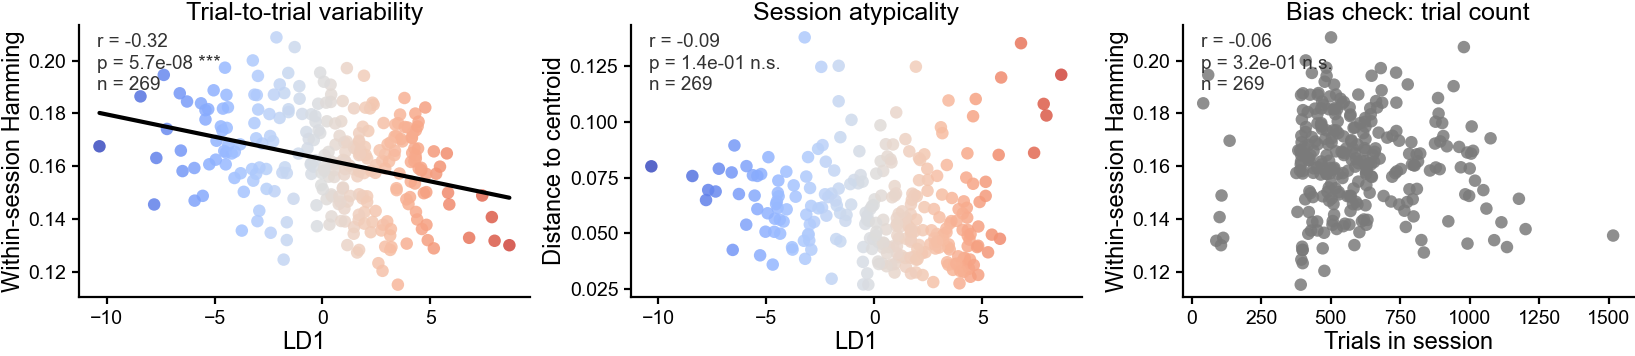

In [16]:
"""
FIGURE 4 -- distance metrics against LD1.
"""
fig, axes = panels(3, kind='single', scale=0.8)

ps.corr_panel(axes[0], merged['lda_1'], merged['hamming_within'],
              xlabel='LD1', ylabel='Within-session Hamming')
axes[0].set_title('Trial-to-trial variability')

ps.corr_panel(axes[1], merged['lda_1'], merged['atypicality'],
              xlabel='LD1', ylabel='Distance to centroid')
axes[1].set_title('Session atypicality')

ps.corr_panel(axes[2], merged['n_trials'], merged['hamming_within'], color=ps.NEUTRAL,
              xlabel='Trials in session', ylabel='Within-session Hamming')
axes[2].set_title('Bias check: trial count')

plt.tight_layout()
ps.savefig(fig, 'distance_variability_vs_ld1')
plt.show()

In [17]:
"""
SUMMARY -- the numbers this notebook stands behind.
"""
print('WITHIN vs BETWEEN MOUSE (session profiles, Hellinger)')
print(f'  within  {dv[same_mouse].mean():.4f} +- {dv[same_mouse].std():.4f}  '
      f'({same_mouse.sum()} pairs)')
print(f'  between {dv[~same_mouse].mean():.4f} +- {dv[~same_mouse].std():.4f}  '
      f'({(~same_mouse).sum()} pairs)   ratio {metric_table.loc[METRIC, "ratio"]:.2f}')
print(f'  per-mouse Wilcoxon p = {w_p:.2e} (n = {n_mice} mice); '
      f'label permutation z = {z_perm:.0f}, p < {1 / N_PERM:.0e}')
print(f'  metric-invariant (as a distance): ' +
      ', '.join(f'{m} {metric_table.loc[m, "ratio_as_distance"]:.2f}' for m in METRICS))
print('\nTRIAL-LEVEL HAMMING (exact, from marginals)')
print(f'  within session {hamming_within.mean():.4f} < across session '
      f'{hx[same_mouse].mean():.4f} < across mouse {hx[~same_mouse].mean():.4f}')
print(f'  per-mouse Wilcoxon p = {p_ws_as:.1e} and {p_as_am:.1e}; '
      f'identity to profile distance holds to {np.nanmax(np.abs(_gap - _sq)):.0e}')
print('\nIDENTIFICATION')
print(f'  {acc:.1%} of held-out sessions assigned to the right mouse out of '
      f'{n_mice_id} (chance {1 / n_mice_id:.1%}, permuted {null_acc.mean():.1%})')
print('\nLD1')
_r, _p = pearsonr(merged['lda_1'], merged['hamming_within'])
print(f'  within-session Hamming vs LD1: r = {_r:+.3f}, p = {_p:.1e}, n = {len(merged)} sessions')

WITHIN vs BETWEEN MOUSE (session profiles, Hellinger)
  within  0.0736 +- 0.0276  (627 pairs)
  between 0.1283 +- 0.0295  (35419 pairs)   ratio 1.74
  per-mouse Wilcoxon p = 1.75e-11 (n = 58 mice); label permutation z = 35, p < 2e-04
  metric-invariant (as a distance): hellinger 1.74, euclidean 1.78, hamming_gap 1.71

TRIAL-LEVEL HAMMING (exact, from marginals)
  within session 0.1619 < across session 0.1667 < across mouse 0.1800
  per-mouse Wilcoxon p = 1.8e-11 and 6.6e-10; identity to profile distance holds to 3e-16

IDENTIFICATION
  78.1% of held-out sessions assigned to the right mouse out of 58 (chance 1.7%, permuted 1.7%)

LD1
  within-session Hamming vs LD1: r = -0.323, p = 5.7e-08, n = 269 sessions
